x shape:  (150, 4)
y shape:  (150,)

 features names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

target names:
['setosa' 'versicolor' 'virginica']

 x_train shape:  (120, 4)
y_train shape:  (120,)
x_test shape:  (30, 4)
y_test shape:  (30,)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.3750 - loss: 0.9206 - val_accuracy: 0.2083 - val_loss: 1.0985
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4583 - loss: 0.8886 - val_accuracy: 0.2083 - val_loss: 1.0663
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5312 - loss: 0.8592 - val_accuracy: 0.2083 - val_loss: 1.0374
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5625 - loss: 0.8339 - val_accuracy: 0.2083 - val_loss: 1.0105
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5833 - loss: 0.8113 - val_accuracy: 0.2500 - val_loss: 0.9872
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6146 - loss: 0.7926 - val_accuracy: 0.3333 - val_loss: 0.9657
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6458 - loss: 0.7761 - val_accuracy: 0.3750 - val_loss: 0.9465
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6146 - loss: 0.7608 - val_accuracy: 0.4167 - val_loss: 0.9281


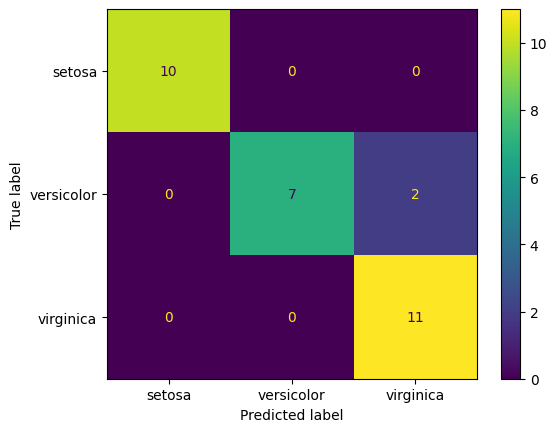

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
import numpy as np

# load iris dataset

iris = load_iris()
# separate features and target
x = iris.data
y = iris.target

# display datasets information
print("x shape: ",x.shape)
print("y shape: ",y.shape)

print("\n features names:")
print(iris.feature_names)

print("\ntarget names:")
print(iris.target_names)

# split dataset into training and testing data
x_train , x_test , y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
    )
# create scaler
scaler = StandardScaler()
# fit scaler on traiing data and transform it
x_train = scaler.fit_transform(x_train)

# tranform test data using the same scaler
x_test = scaler.transform(x_test)

# check shapes
print("\n x_train shape: ",x_train.shape)
print("y_train shape: ",y_train.shape)
print("x_test shape: ",x_test.shape)
print("y_test shape: ",y_test.shape)

# create the mlp
model = keras.Sequential([
    keras.layers.Dense(16,activation="relu",input_shape=(4,)),
    keras.layers.Dense(8,activation = "relu"),
    keras.layers.Dense(3,activation="softmax")
])

model.summary()

model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

# train the model
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)
# evaluation
test_loss,test_accuracy = model.evaluate(x_test , y_test)

print("test loss: ",test_loss)
print("test accuracy: ",test_accuracy)
print("test accuracy(%): ",test_accuracy*100)

# predict probabilities for test data
y_pred_prob = model.predict(x_test)

# convert probabilities into class numbers
y_pred = np.argmax(y_pred_prob,axis=1)

print("predicted classess:")
print(y_pred)

print("\nactual classes:")
print(y_test)

# confusion matrix

cm=confusion_matrix(y_test , y_pred)

print("\n confusion matrix: ")
print(cm)

# display cnonfusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
    )
disp.plot()


